### FIFA World Cup 2026: Consumer Spending Accommodations and Food EDA
#### Exploring restaurant and hotel spending trends across host and control cities.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading in data
df = pd.read_csv("../data/raw/Affinity - City - Monthly.csv")
cities = pd.read_csv("../data/raw/GeoIDs - City.csv")
print(df.shape)
print(cities.shape)
print(df.head())
print(cities.head())

(4004, 42)
(53, 8)
   year  month  day_endofmonth  cityid freq  spend_aap  spend_s_aap  \
0  2020      1              31       1    m        0.0          0.0   
1  2020      1              31       2    m        0.0          0.0   
2  2020      1              31       3    m        0.0          0.0   
3  2020      1              31       4    m        0.0          0.0   
4  2020      1              31       5    m        0.0          0.0   

      spend_acf   spend_s_acf  spend_aer  ...  spend_s_sgh  spend_tws  \
0 -1.980000e-08  1.820000e-08        0.0  ...          0.0        0.0   
1  2.830000e-09 -3.830000e-08        0.0  ...          0.0        0.0   
2  4.270000e-08  4.270000e-08        0.0  ...          0.0        0.0   
3  3.610000e-08  0.000000e+00        0.0  ...          0.0        0.0   
4  2.240000e-08  0.000000e+00        0.0  ...          0.0        0.0   

   spend_s_tws  spend_inperson  spend_s_inperson  spend_retail_no_grocery  \
0          0.0    1.480000e-08      1.

In [3]:
# Data cleaning and filtering

# Filtering df to only include necessary columns, cities of interest, and dates

df_filtered = df[['year', 'month', 'day_endofmonth', 'cityid', 'spend_all', 'spend_acf']]
df_filtered['spend_acf'].dtype
df_filtered.replace('.', np.nan, inplace=True)
df_filtered = df_filtered.dropna()
#print(df_filtered.head())

# Filter cities dataframe for necessary features
cities_filtered = cities[['cityid', 'cityname', 'stateabbrev', 'city_pop2019']]
#print(cities_filtered.head())

# merging dataframse to match cityid to cities
df_merged = pd.merge(df_filtered, cities_filtered, on='cityid')
#print(df_merged.head())

# Filter to cities of interest 
target_cities = ['Los Angeles', 'Denver', 'Dallas', 'Chicago', 'Boston', 'Atlanta', 'Kansas City', 'Austin', 'Charlotte']
worldcup_city_spending = df_merged[df_merged['cityname'].isin(target_cities)]
#print(worldcup_city_spending.head())

# Adding a date column
worldcup_city_spending = worldcup_city_spending.rename(columns={'day_endofmonth': 'day'})
worldcup_city_spending['Date'] = pd.to_datetime(worldcup_city_spending[['year', 'month', 'day']])
#print(worldcup_city_spending.iloc[14:44])

# Removing unnecessary columns and setting date as index
worldcup_city_spending = worldcup_city_spending.drop(columns=['year', 'month', 'day', 'cityid'])
worldcup_city_spending = worldcup_city_spending.set_index('Date')

# Filtering so date starts from January 2022 so COVID spending does not affect data
worldcup_city_spending = worldcup_city_spending[worldcup_city_spending.index >= '2022-01-01']
print(worldcup_city_spending)

worldcup_city_spending.groupby('cityname').size()


            spend_all  spend_acf     cityname stateabbrev  city_pop2019
Date                                                                   
2022-01-31    -0.1300    -0.1580  Los Angeles          CA      10039107
2022-01-31     0.1810     0.0257      Chicago          IL       5150233
2022-01-31    -0.0201    -0.0351       Dallas          TX       2635516
2022-01-31     0.0388     0.0112       Austin          TX       1273954
2022-01-31    -0.0339    -0.0717    Charlotte          NC       1110356
...               ...        ...          ...         ...           ...
2026-05-31     0.1660     0.0668    Charlotte          NC       1110356
2026-05-31     0.4430     0.2690       Boston          MA        803907
2026-05-31     0.1990     0.0688       Denver          CO        727211
2026-05-31     0.3280     0.1950      Atlanta          GA       1063937
2026-05-31     0.2280     0.3290  Kansas City          MO        703011

[477 rows x 5 columns]


cityname
Atlanta        53
Austin         53
Boston         53
Charlotte      53
Chicago        53
Dallas         53
Denver         53
Kansas City    53
Los Angeles    53
dtype: int64

In [4]:
# Ensure data types are correct 

worldcup_city_spending.dtypes

# Creating csv of cleaned data
worldcup_city_spending.to_csv('../data/processed/worldcup_city_spending.csv')

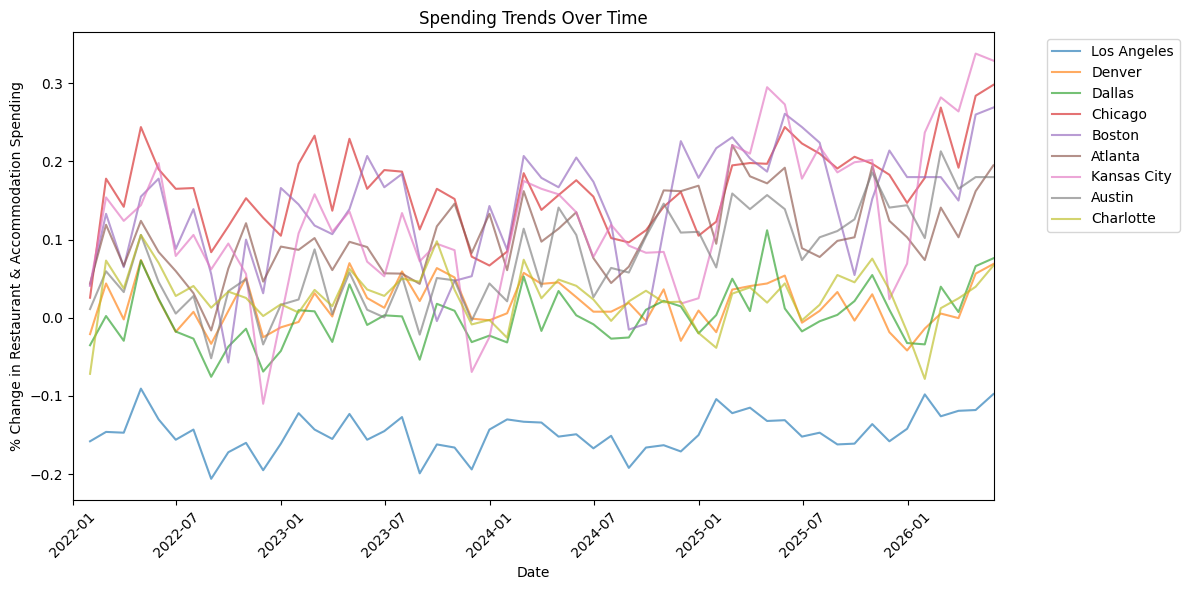

In [5]:
# Creating line plots for each city to visualize spending trends over time (past 6 years)

plt.figure(figsize=(12, 6))
for city in target_cities:
    city_data = worldcup_city_spending[worldcup_city_spending['cityname'] == city]
    plt.plot(city_data.index, city_data['spend_acf'], label=city, alpha=0.65)

plt.title("Spending Trends Over Time")
plt.xlabel("Date")
plt.ylabel("% Change in Restaurant & Accommodation Spending")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.xlim([pd.Timestamp('2022-01-01'), pd.Timestamp('2026-06-01')])

# Adding figure to outputs folder
plt.savefig('../outputs/EDA_figures/spending_trends.png', bbox_inches='tight', dpi=150)

plt.show()
plt.close()




This line plot shows percent change of consumer spending on accommodations and food from January 2022 to May 2026 (right before the world cup) expressed as percent change from a pre-pandemic baseline. The 2020-2021 COVID period was excluded as it introduced significant distortions unrelated to normal seasonal patterns. After the COVID period, all cities experienced steady increases in consumer spending on accommodations and food. Economic recovery varied by city with Kansas City being at the top of consumer spending and Los Angeles lagging behind other cities. We can see consumer spending on food and accommodations dips around the start of each year suggesting a consistent seasonal pattern in restaurant and hotel spending, strengthening the use of a seasonal time series model for forecasting.

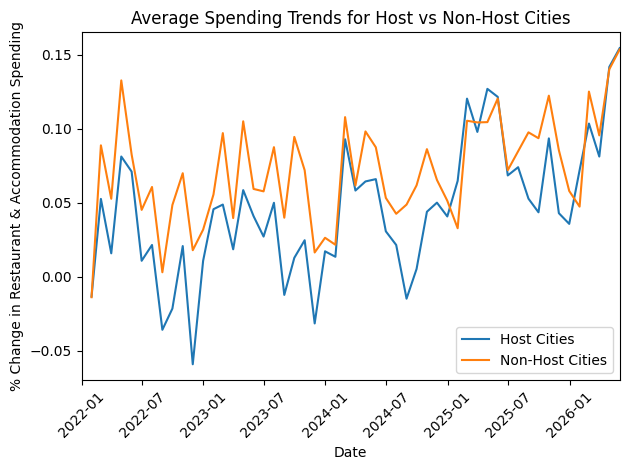

In [6]:
# Comparing host and non-host cities to see if there is a significant difference in spending trends

# Df of host cities 
host_cities = ['Los Angeles', 'Atlanta', 'Dallas', 'Boston', 'Kansas City']
df_host = worldcup_city_spending[worldcup_city_spending['cityname'].isin(host_cities)]
# Df of non-host cities
nonhost_cities = ['Denver', 'Chicago', 'Austin', 'Charlotte']
df_nonhost = worldcup_city_spending[worldcup_city_spending['cityname'].isin(nonhost_cities)]

# Finding average spending for host and non-host cities by date
host_avg = df_host.groupby("Date")['spend_acf'].mean()
nonhost_avg = df_nonhost.groupby("Date")['spend_acf'].mean()

# Line graph to show average spending trends for host and control (non-host) cities
plt.plot(host_avg.index, host_avg, label = "Host Cities")
plt.plot(nonhost_avg.index, nonhost_avg, label = "Non-Host Cities")
plt.title("Average Spending Trends for Host vs Non-Host Cities")
plt.xlabel("Date")
plt.ylabel("% Change in Restaurant & Accommodation Spending")
plt.legend()
plt.xlim([pd.Timestamp('2022-01-01'), pd.Timestamp('2026-06-01')])
plt.xticks(rotation=45)
plt.tight_layout()

# Adding figure to outputs folder
plt.savefig('../outputs/EDA_figures/host_vs_nonhost.png', bbox_inches='tight', dpi=150)

plt.show()
plt.close()

From January 2022 to May 2026 host and non-host cities tracked closely in historical restaurant and hotel spending patterns, validating the control group selection. Since both groups behaved similarly before the World Cup, any significant divergence in spending during June and July 2026 can be attributed to the World Cup rather than pre-existing differences between cities.


   season host_status  spend_acf
0    Fall        Host   0.018654
1    Fall    Non-Host   0.069367
2  Spring        Host   0.079764
3  Spring    Non-Host   0.095703
4  Summer        Host   0.024370
5  Summer    Non-Host   0.057615
6  Winter        Host   0.050233
7  Winter    Non-Host   0.059522


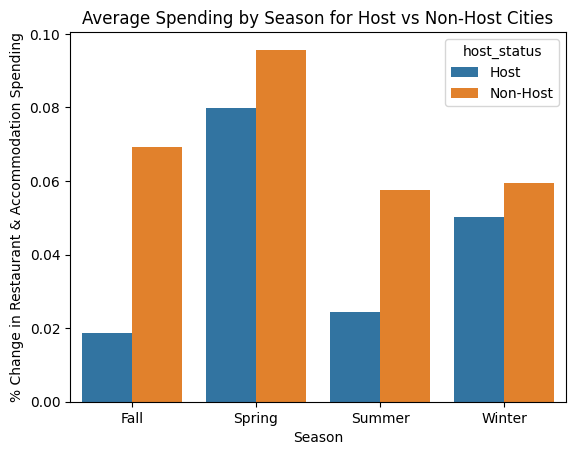

In [7]:
# Grouped bar chat to analyze average spending for host and non-host cities by season

# Function to pull season from date

def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

worldcup_city_spending['season'] = worldcup_city_spending.index.map(get_season)
worldcup_city_spending['season'].value_counts()
# Test to see if correctly added season column
# print(worldcup_city_spending.head())

# Adding host/non-host column

worldcup_city_spending['host_status'] = worldcup_city_spending['cityname'].apply(lambda x: 'Host' if x in host_cities else 'Non-Host')
worldcup_city_spending['host_status'].value_counts()
# Test to see if correctly added host_status column
# print(worldcup_city_spending.head())

# Grouping by season and host status to find average spending
seasonal_avg = worldcup_city_spending.groupby(['season', 'host_status'])['spend_acf'].mean().reset_index()
print(seasonal_avg)


# Adding updated dataframe to processed data file
worldcup_city_spending.to_csv('../data/processed/worldcup_city_seasonal_spending.csv')

# Generating bar chart 
sns.barplot(data=seasonal_avg, x='season', y='spend_acf', hue='host_status')
plt.title("Average Spending by Season for Host vs Non-Host Cities")
plt.xlabel("Season")
plt.ylabel("% Change in Restaurant & Accommodation Spending")
plt.savefig('../outputs/EDA_figures/host_vs_nonhost_seasonal.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()


This grouped bar chart compares average restaurant and hotel spending across seasons for host and non-host cities from January 2022 to May 2026. Non-host cities consistently outperform host cities in every season, largely driven by Los Angeles persistently lagging below other cities in the dataset. Spring represents the peak spending season for both groups, with Summer having a noticeable gap between host and non-host cities.

This seasonal baseline is critical for our World Cup analysis, if host city spending during June and July 2026 closes or exceeds the non-host average, that divergence can be attributed to the World Cup effect rather than normal seasonal patterns. We will use SARIMA to forecast the expected Summer 2026 baseline for each city and measure any deviation from it as the tournament occurs.